In [4]:
import shutil
from pathlib import Path

# Rutas base
RUNS_DIR = Path('../notebooks/runs/notebooks/runs/models')
FIGURES_DIR = Path('../figures')

# Crear carpetas
modelos = {
    'v1_yolov8n': Path('../notebooks/runs/models/visdrone_yolov8n'),
    'v2_yolov8s': Path('../notebooks/runs/notebooks/runs/models/visdrone_yolov8s_640'),
    'v3_yolov8n_tuned': Path('../notebooks/runs/notebooks/runs/models/visdrone_yolov8n_tuned')
}

for carpeta in modelos.keys():
    (FIGURES_DIR / carpeta).mkdir(parents=True, exist_ok=True)

print("Carpetas creadas")

Carpetas creadas


In [5]:
# Archivos a copiar de cada modelo
archivos = ['results.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'BoxF1_curve.png']


for nombre_carpeta, modelo_dir in modelos.items():
    figures_dir = FIGURES_DIR / nombre_carpeta
    for archivo in archivos:
        src = modelo_dir / archivo
        if src.exists():
            shutil.copy(src, figures_dir / archivo)
            print(f"Copiado: {nombre_carpeta}/{archivo}")
        else:
            print(f"No encontrado: {nombre_carpeta}/{archivo}")

Copiado: v1_yolov8n/results.png
Copiado: v1_yolov8n/confusion_matrix_normalized.png
Copiado: v1_yolov8n/BoxPR_curve.png
Copiado: v1_yolov8n/BoxF1_curve.png
Copiado: v2_yolov8s/results.png
Copiado: v2_yolov8s/confusion_matrix_normalized.png
Copiado: v2_yolov8s/BoxPR_curve.png
Copiado: v2_yolov8s/BoxF1_curve.png
No encontrado: v3_yolov8n_tuned/results.png
No encontrado: v3_yolov8n_tuned/confusion_matrix_normalized.png
No encontrado: v3_yolov8n_tuned/BoxPR_curve.png
No encontrado: v3_yolov8n_tuned/BoxF1_curve.png


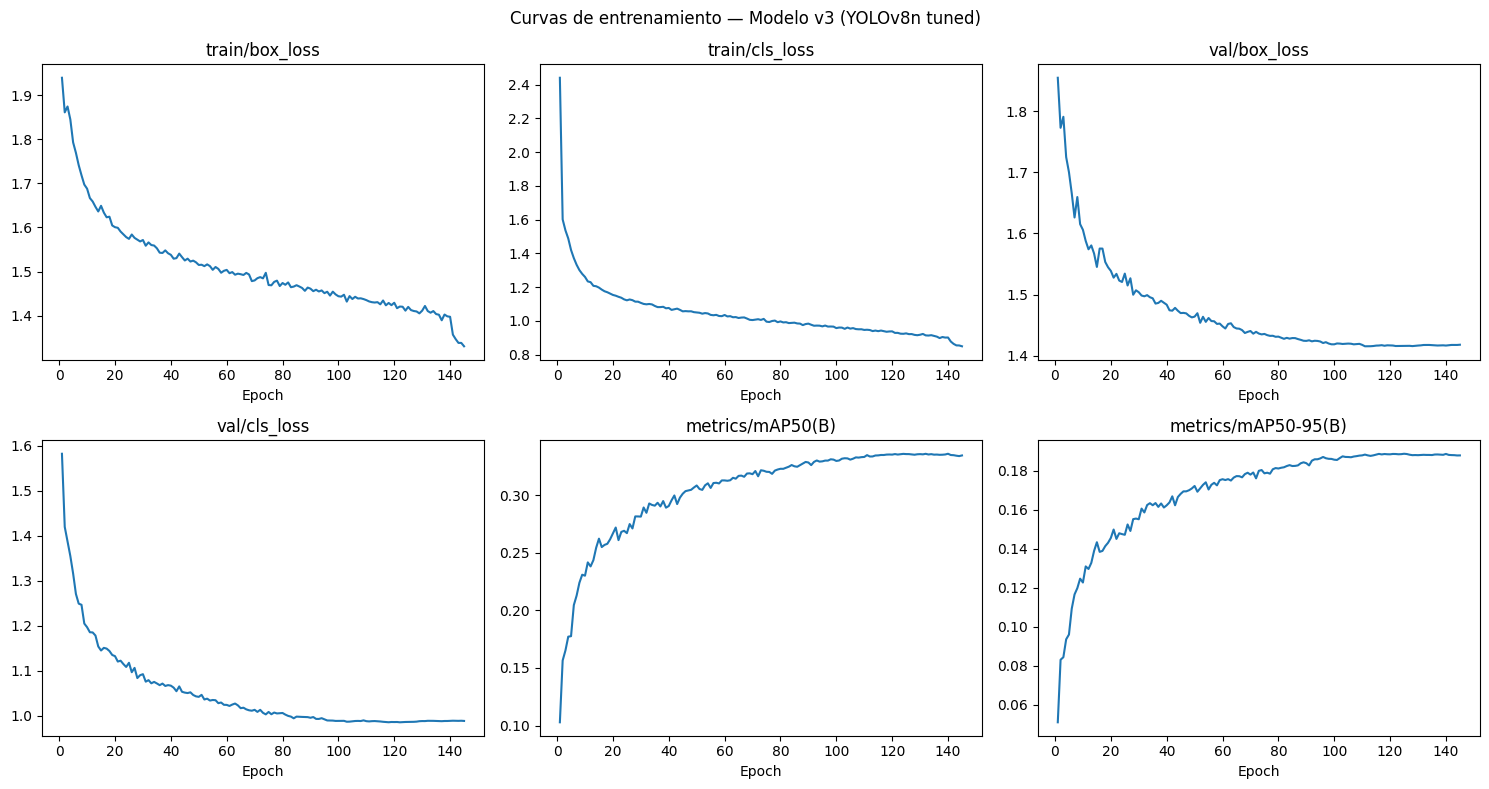

Guardado


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

v3_dir = Path('../notebooks/runs/notebooks/runs/models/visdrone_yolov8n_tuned')
df_v3 = pd.read_csv(v3_dir / 'results.csv')
df_v3.columns = df_v3.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cols = ['train/box_loss', 'train/cls_loss', 'val/box_loss', 
        'val/cls_loss', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']

for i, col in enumerate(cols):
    axes[i].plot(df_v3['epoch'], df_v3[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Epoch')

plt.suptitle('Curvas de entrenamiento — Modelo v3 (YOLOv8n tuned)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'v3_yolov8n_tuned' / 'results.png', dpi=150)
plt.show()
print("Guardado")